# Titanic EDA — Zepto Data & AI Platform Capstone

Loads the seaborn Titanic dataset exactly once, saves it to `titanic.csv`, and
profiles it before any cleaning or modeling decisions are made. This is the ONLY
call to `sns.load_dataset` in the entire analytics module — the modeling notebook
(`02_modeling.ipynb`) reads `titanic.csv` instead, never reloads from seaborn.


In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")
df.to_csv("titanic.csv", index=False)

print(df.shape)
df.head()


(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Profile

`.info()` and `.describe()` first, then the real missing-value percentage for every
affected column — this is what the threshold rule (next section) gets applied to.


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
missing_pct = (df.isnull().mean() * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
missing_pct


deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64

## Missing-value threshold rule

Measured percentages (from the cell above): `deck` 77.22%, `age` 19.87%,
`embarked` 0.22%, `embark_town` 0.22%.

Applying the assignment's threshold rule:

- **`deck` (77.22% missing) — very high, column dropped.** Imputing three-quarters
  of a column would fabricate more data than it preserves, and encoding "missing"
  as its own category would still leave a feature that is 77% one value. `deck`
  is not part of the required 6-column correlation matrix either, so dropping it
  costs nothing downstream.
- **`age` (19.87% missing) — within the 5-30% band, imputed with the median.**
  Median is robust to outliers (a few very old/young passengers won't skew it the
  way a mean would).
- **`embarked` and `embark_town` (0.22% missing each, same 2 rows) — below 5%,
  rows dropped.** Only 2 of 891 rows are affected, so dropping them loses
  negligible information versus inventing a boarding port for 2 passengers.

**Important scope note:** the cleaning below is for this EDA notebook only (so
charts and the correlation matrix can be computed on complete data). The modeling
notebook (`02_modeling.ipynb`) reads a **fresh** copy of `titanic.csv` — still
containing the real NaNs — and performs its own leakage-safe imputation via
`ColumnTransformer`, fit only on the training split. This EDA-stage cleaning is
never reused for modeling, so it can't leak test-set information into the model.



In [5]:
df_eda = df.copy()

# deck: 77.22% missing -- too sparse to impute or encode reliably; dropped entirely.
df_eda = df_eda.drop(columns=["deck"])

# embarked/embark_town: 0.22% missing (2 rows) -- below the 5% threshold, dropped.
df_eda = df_eda.dropna(subset=["embarked", "embark_town"])

# age: 19.87% missing -- within the 5-30% threshold, imputed with the median.
df_eda["age"] = df_eda["age"].fillna(df_eda["age"].median())

print(df_eda.shape)
df_eda.isnull().sum()


(889, 14)


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## Univariate analysis: age and fare

Histogram + boxplot for each, IQR-based outlier counts, and fare's mean/median/mode
for the skewness verdict.


C:\Users\Karan\AppData\Local\Temp\ipykernel_12880\1264787828.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_eda["age"], vert=True)


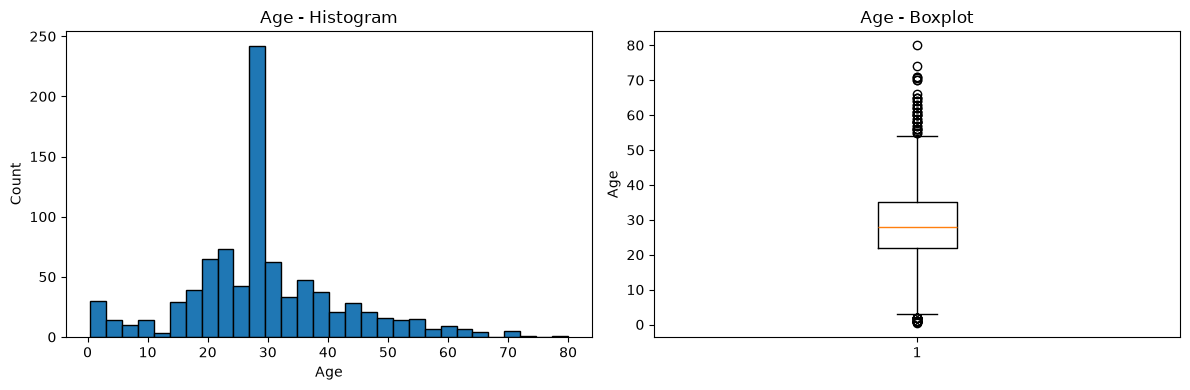

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_eda["age"], bins=30, edgecolor="black")
axes[0].set_title("Age - Histogram")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].boxplot(df_eda["age"], vert=True)
axes[1].set_title("Age - Boxplot")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.savefig("charts/age_univariate.png", dpi=100)
plt.show()


C:\Users\Karan\AppData\Local\Temp\ipykernel_12880\4209642221.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_eda["fare"], vert=True)


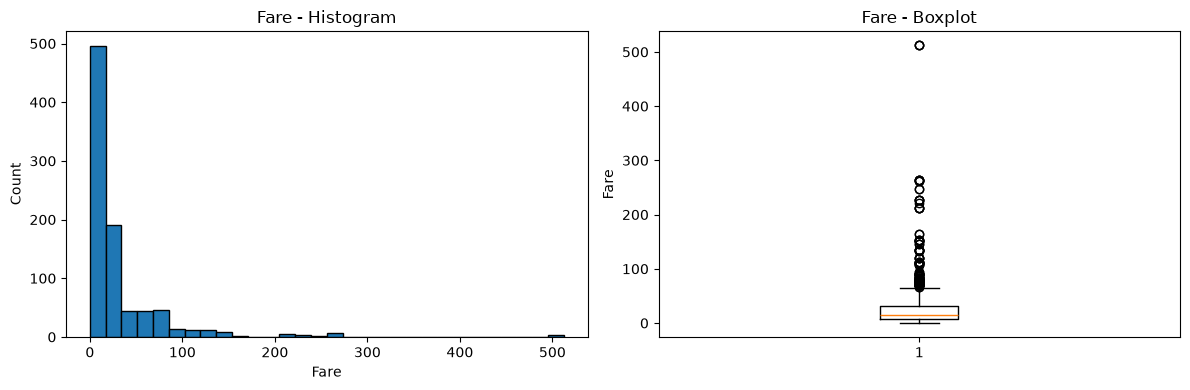

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_eda["fare"], bins=30, edgecolor="black")
axes[0].set_title("Fare - Histogram")
axes[0].set_xlabel("Fare")
axes[0].set_ylabel("Count")

axes[1].boxplot(df_eda["fare"], vert=True)
axes[1].set_title("Fare - Boxplot")
axes[1].set_ylabel("Fare")

plt.tight_layout()
plt.savefig("charts/fare_univariate.png", dpi=100)
plt.show()


In [8]:
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum(), lower, upper

age_outliers, age_lower, age_upper = iqr_outlier_count(df_eda["age"])
fare_outliers, fare_lower, fare_upper = iqr_outlier_count(df_eda["fare"])

print(f"age: {age_outliers} outliers (bounds: {age_lower:.2f} to {age_upper:.2f})")
print(f"fare: {fare_outliers} outliers (bounds: {fare_lower:.2f} to {fare_upper:.2f})")


age: 65 outliers (bounds: 2.50 to 54.50)
fare: 114 outliers (bounds: -26.76 to 65.66)


In [9]:
fare_mean = df_eda["fare"].mean()
fare_median = df_eda["fare"].median()
fare_mode = df_eda["fare"].mode()[0]

print(f"fare mean: {fare_mean:.2f}")
print(f"fare median: {fare_median:.2f}")
print(f"fare mode: {fare_mode:.2f}")


fare mean: 32.10
fare median: 14.45
fare mode: 8.05


### Skewness verdict for fare

`fare` is strongly right-skewed: **mode (8.05) < median (14.45) < mean (32.10)**.
When the mean sits well above both the median and the mode, it means a small
number of very high values (visible in the boxplot as points far above the
IQR fence, and in the histogram as the long, sparse tail out past 100 toward
512) are pulling the average upward while the bulk of the data stays low. The
114 IQR-flagged outliers in `fare` are consistent with this: most passengers
paid a modest fare, but a minority paid substantially more, stretching the
distribution's right tail and inflating the mean well past what a "typical"
passenger paid.

`age`, by contrast, has a much smaller mean-median gap and a roughly bell-shaped
histogram (allowing for the concentration of imputed values at the median from
the missing-value fill) — its 65 IQR outliers sit at both the low end (infants)
and high end (elderly passengers), not a one-sided tail like `fare`.
